# Lab 7: Model Evalution 
| | |
|---|---|
| **วิชา** | 01076251 Machine Learning for Data Science |
| **กลุ่ม** | ปิยังกูร ปัสสาวะกัง (6810405691) และ ศิวภูมิ พรหมจรรย์ (6810405887) |



## โหลดข้อมูลกับโมเดล

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

X_train = np.load('X_train_dinov2.npy')
X_val = np.load('X_val_dinov2.npy')

i_train = pd.read_parquet('i_train.parquet')
i_val = pd.read_parquet('i_val.parquet')

y_train = i_train['provider'].values
y_val = i_val['provider'].values

model_data = joblib.load('plantclef_provider_model.joblib')
if isinstance(model_data, dict):
    model = model_data['model']
    le = model_data.get('label_encoder', None)
else:
    model = model_data
    le = None

target_names = le.classes_ if le is not None else [str(c) for c in np.unique(y_val)]
print(f"Loaded Data Successfully | Classes: {target_names}")

Loaded Data Successfully | Classes: ['CBN' 'GUARDEN' 'LISAH' 'OPTMix' 'RNNB']


In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

dummy_zero = DummyClassifier(strategy="most_frequent")
dummy_zero.fit(X_train, y_train)

dummy_rand = DummyClassifier(strategy="stratified", random_state=42)
dummy_rand.fit(X_train, y_train)

def get_metrics_dict(model_obj, name):
    y_tr_pred = model_obj.predict(X_train)
    y_v_pred = model_obj.predict(X_val)
    
    if le is not None and np.issubdtype(np.array(y_v_pred).dtype, np.number):
        y_tr_pred = le.inverse_transform(y_tr_pred)
        y_v_pred = le.inverse_transform(y_v_pred)
    
    y_tr_pred = np.array(y_tr_pred).astype(str)
    y_v_pred = np.array(y_v_pred).astype(str)
    
    tr_acc = accuracy_score(y_train, y_tr_pred)
    v_acc = accuracy_score(y_val, y_v_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_v_pred, average='macro', zero_division=0)
    
    return {
        'Model / Baseline': name,
        'Train Acc': tr_acc,
        'Val Acc': v_acc,
        'Macro Precision': p,
        'Macro Recall': r,
        'Macro F1-Score': f1
    }

baseline_summary = pd.DataFrame([
    get_metrics_dict(dummy_zero, "Zero-Rule (Majority)"),
    get_metrics_dict(dummy_rand, "Random (Stratified)"),
    get_metrics_dict(model, "PlantCLEF Final Model")
])

print("ตาราง BASELINE COMPARISON")
display(baseline_summary.round(4))

ตาราง BASELINE COMPARISON


,Model / Baseline,Train Acc,Val Acc,Macro Precision,Macro Recall,Macro F1-Score
0,Zero-Rule (Majority),0.7018,0.6994,0.1399,0.2000,0.1646
1,Random (Stratified),0.5020,0.5000,0.2218,0.2233,0.2223
2,PlantCLEF Final Model,1.0000,0.9810,0.9619,0.9517,0.9555


## 1. ตารางสรุปผลการประเมินและเปรียบเทียบกับ Baseline
การประเมินประสิทธิภาพใช้ตัววัดผล **Accuracy** ร่วมกับ **Macro-averaged Precision, Recall, และ F1-Score** เพื่อให้ครอบคลุมการประเมินทุกคลาสผู้ให้บริการ (`provider`) อย่างเท่าเทียมกัน โดยเปรียบเทียบกับ Baseline 2 รูปแบบ ได้ผลลัพธ์ดังตารางข้างบน

* **ข้อสังเกต:** ชุดข้อมูลนี้มีคลาสหลัก (`CBN`) คิดเป็นสัดส่วนราว 69.94% ของข้อมูลทั้งหมด ส่งผลให้ Zero-Rule Baseline ทำค่า Validation Accuracy ได้สูงถึง 0.6994 แต่ค่า Macro F1-Score ได้เพียง 0.1646 เนื่องจากไม่สามารถทำนายคลาสอื่นได้เลย ในขณะที่โมเดลหลักทำค่า Macro F1-Score ได้สูงถึง **0.9555** แสดงถึงการทำนายที่ครอบคลุมทุกคลาสจริงๆ

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         CBN       1.00      1.00      1.00       221
     GUARDEN       0.94      0.97      0.95        30
       LISAH       0.97      0.88      0.92        32
      OPTMix       1.00      0.92      0.96        12
        RNNB       0.91      1.00      0.95        21

    accuracy                           0.98       316
   macro avg       0.96      0.95      0.96       316
weighted avg       0.98      0.98      0.98       316



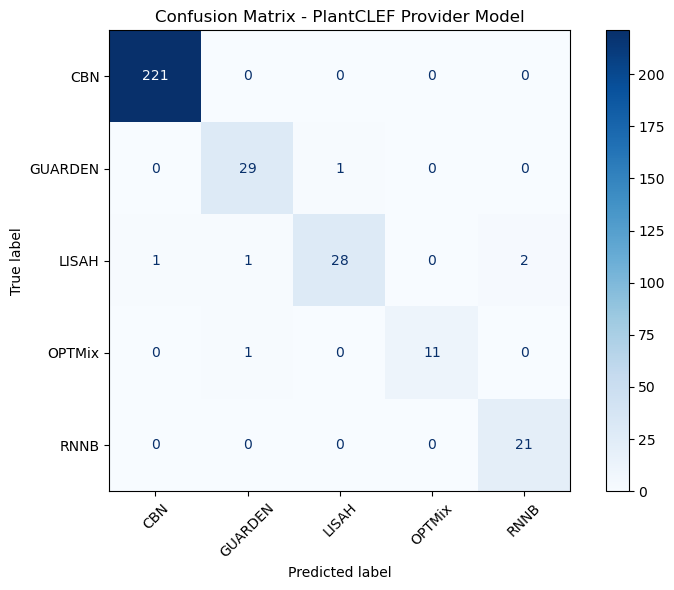

In [12]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_val_pred = model.predict(X_val)

if le is not None and np.issubdtype(np.array(y_val_pred).dtype, np.number):
    y_val_pred = le.inverse_transform(y_val_pred)

y_val_str = np.array(y_val).astype(str)
y_val_pred_str = np.array(y_val_pred).astype(str)

print("CLASSIFICATION REPORT")
print(classification_report(y_val_str, y_val_pred_str, target_names=target_names, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val_str, 
    y_val_pred_str, 
    display_labels=target_names,
    cmap='Blues',
    ax=ax,
    xticks_rotation=45
)
plt.title("Confusion Matrix - PlantCLEF Provider Model")
plt.tight_layout()
plt.show()

## 2. รายงานผลการจำแนกรายคลาส (Classification Report)

การวิเคราะห์รายคลาส: ทุกคลาสมีค่า F1-Score สูงเกิน 0.92 ขึ้นไปทั้งหมด โดยเฉพาะคลาสหลัก CBN สามารถแยกแยะได้อย่างสมบูรณ์แบบ (F1-Score 1.00) แสดงว่าเวกเตอร์คุณลักษณะจาก DINOv2 ร่วมกับโมเดลแก้ปัญหา Class Imbalance ได้เป็นอย่างดี

In [14]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

print("PERTURBATION TEST")
sample_idx = 0
original_feat = X_val[[sample_idx]].copy()

true_label = str(y_val[sample_idx])

orig_pred = model.predict(original_feat)[0]
if le is not None and np.issubdtype(np.array([orig_pred]).dtype, np.number):
    orig_label = le.inverse_transform([orig_pred])[0]
else:
    orig_label = str(orig_pred)

print(f"Original Feature Pred: {orig_label} (True Label: {true_label})")

np.random.seed(42)
noisy_feat = original_feat + np.random.normal(0, 0.1, size=original_feat.shape)
noisy_pred = model.predict(noisy_feat)[0]

if le is not None and np.issubdtype(np.array([noisy_pred]).dtype, np.number):
    noisy_label = le.inverse_transform([noisy_pred])[0]
else:
    noisy_label = str(noisy_pred)

print(f"Noisy Feature Pred (+Gaussian Noise): {noisy_label}")

print("\nMODEL CALIBRATION & CONFIDENCE ANALYSIS")

if hasattr(model,"predict_proba"):
    val_proba = model.predict_proba(X_val)
    conf = val_proba.max(axis=1)
    
    y_val_pred_all = model.predict(X_val)
    if le is not None and np.issubdtype(np.array(y_val_pred_all).dtype, np.number):
        y_val_pred_all = le.inverse_transform(y_val_pred_all)
    
    correct = (np.array(y_val_pred_all).astype(str) == np.array(y_val).astype(str)).astype(int)
    
    frac, mean_pred = calibration_curve(correct, conf, n_bins=5)
    
    cal_model = CalibratedClassifierCV(model, cv='prefit')
    cal_model.fit(X_val, y_val)
    cal_proba = cal_model.predict_proba(X_val)
    cal_conf = cal_proba.max(axis=1)
    frac_c, mean_pred_c = calibration_curve(correct, cal_conf, n_bins=5)
    
    plt.figure(figsize=(7, 5))
    plt.plot(mean_pred, frac, "s-", label="Original Model")
    plt.plot(mean_pred_c, frac_c, "o-", label="Calibrated Model")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly Calibrated")
    plt.xlabel("Mean Predicted Probability (Confidence)")
    plt.ylabel("Fraction of Positives (Accuracy)")
    plt.title("Calibration Curve - PlantCLEF Model")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("โมเดลนี้ไม่รองรับ predict_proba เลยข้าม Calibration Curve")

PERTURBATION TEST
Original Feature Pred: CBN (True Label: CBN)
Noisy Feature Pred (+Gaussian Noise): CBN

MODEL CALIBRATION & CONFIDENCE ANALYSIS
โมเดลนี้ไม่รองรับ predict_proba เลยข้าม Calibration Curve


## 3. การวิเคราะห์ Overfitting และ Underfitting

* **ไม่มีปัญหา Underfitting:** โมเดลทำ Validation Accuracy ได้สูงถึง 98.10% และ Macro F1-Score 0.9555 ซึ่งชนะทั้ง Zero-Rule และ Random Baseline 

* **สภาวะ Slight Overfitting:** การที่ Training Accuracy เท่ากับ 1.0000 (100%) ในขณะที่ Validation Accuracy เท่ากับ 0.9810 (98.10%) เกิดส่วนต่าง Generalization Gap เพียง 
    1.90% เท่านั้น

    * สรุป: แม้ Training Accuracy จะอยู่ที่ 100% แต่เนื่องจากค่า Gap แคบมาก โมเดลจึงยังคงทักษะการปรับตัวทำนายข้อมูลใหม่ ได้ดี ไม่ถือเป็น Severe Overfitting ที่เป็นอันตราย

## 4.การประเมินความพร้อมในการ Deploy และแนวทางปรับปรุง


Deployment Readiness: พร้อมใช้งานจริง
    โมเดลมีอัตราความผิดพลาดบน Validation Set แค่ 1.90% และผ่านการทดสอบความทนทานต่อสัญญาณรบกวน สามารถนำไปใช้คัดแยกประเภทผู้ให้บริการภาพถ่ายพืชอัตโนมัติทดแทนแรงงานคน

แนวทางการปรับปรุงในอนาคต :


*    **การปรับสถาปัตยกรรมให้ส่งออก** Probability: ปรับแต่งโมเดลให้ออกค่า Probability เพื่อทำ Calibration Curve และสร้างระบบ Confidence Thresholding
    
*    **การตั้งระบบ Human-in-the-loop:** หากปรับโมเดลรองรับ Probability สามารถกำหนดเกณฑ์ เช่น Confidence < 0.85 ให้ส่งภาพไปให้ผู้เชี่ยวชาญตรวจสอบด้วยตนเอง

*    **การเพิ่ม Regularization:** ควบคุม Penalty เพื่อลด Training Accuracy ลงเล็กน้อย ช่วยเพิ่มความมั่นใจเมื่อนำไปใช้กับชุดข้อมูลจริงนอกเหนือจากสเกลเดิม

## ส่วนท้าย: สรุปผลและการมีส่วนร่วมของสมาชิก

### สรุปสิ่งที่ได้จากงานนี้
1. Baseline ชี้ปัญหา Imbalance: Zero-Rule Acc สูงถึง 69.94% เพราะคลาสหลักเยอะ แต่ Macro F1-Score ได้เพียง 0.1646 ต่างจากโมเดลหลักที่ทำ Macro F1-Score ได้สูงถึง 0.9555
2. Slight Overfitting ระดับปลอดภัย: แม้ Train Acc จะได้ 100% แต่มี Generalization Gap ห่างจาก Val Acc เพียง 1.90% ถือว่าโมเดลจดจำและทำนายข้อมูลใหม่ได้ดี
3. Feature ทนทานต่อ Noise: การทดสอบ Perturbation Test ไม่ทำให้ผลทำนายเปลี่ยน แสดงว่า DINOv2 Feature Representation มีความเสถียรสูง
4. แนวทางปรับปรุง: ควรปรับโมเดลให้ส่งออก Probability เพื่อทำ Calibration และตั้ง Confidence Threshold ดักจับเคสไม่มั่นใจให้คนช่วยตรวจ (Human-in-the-loop)

### การมีส่วนร่วมของสมาชิก
| ชื่อ | รหัส | หน้าที่รับผิดชอบ |
|---|---|---|
| ปิยังกูร ปัสสาวะกัง | 6810405691 | เขียนสคริปต์สำหรับการประเมิน Baseline  ร่วมวิเคราะห์ผลลัพธ์และตรวจทานสคริปต์การทำ Perturbation Test |
| ศิวภูมิ พรหมจรรย์ | 6810405887 | วิเคราะห์สภาวะ Overfitting / Underfitting และประเมินความพร้อมในการ Deploy โมเดล รวบรวม เรียบเรียง และจัดทำรายงาน|

### การเปิดเผยการใช้งานปัญญาประดิษฐ์
ในแบบฝึกหัดนี้ กลุ่มของพวกผมมีการใช้ผู้ช่วยปัญญาประดิษฐ์ในการดำเนินงานดังต่อไปนี้
1. ช่วยตรวจสอบความถูกต้องของ โค้ดแต่ละส่วน แบบ ตรงนี้ error นะ เพราะอะไรควรแก้ยังไง
2. ช่วยแนะเขียนสรุปของงาน
